# Chapter 3: Classification

## 1. Quick look at MNIST Dataset

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False) # We download data as a NumPy array

In [2]:
# We split the dataset
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [3]:
y.shape

(70000,)

In [4]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
  image = image_data.reshape(28, 28)
  plt.imshow(image, cmap='binary')
  plt.axis('off')

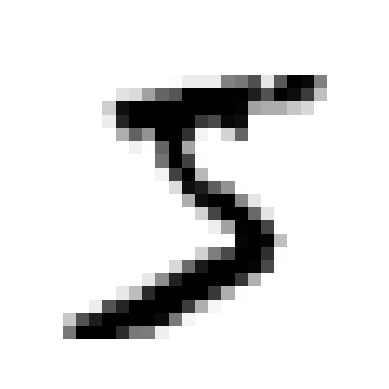

In [5]:
# Showing a digit from this dataset
some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [6]:
y[0]

'5'

Before diving deeper, let's split data. This dataset returned by fetch_opneml is splitted already.

In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## 2. Binary Classification: A 5-detector

In [8]:
# Creating new target vectors
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

The model we're using now for our 5-detector is Stocastic Gradient Descent model

In [9]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [10]:
# It can make predictions now
sgd_clf.predict([some_digit])

array([ True])

### 2.1. Meassuring accuracy using Cross-Validation

In [11]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In cross-validation, the model got scores above 95%. However, it might have been influenced by the most frequent class: the non-5 digits.

In [12]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(dummy_clf.predict(X_train))

[False False False ... False False False]


In [13]:
cross_val_score(dummy_clf, X_train, y_train_5, scoring='accuracy', cv=3)

array([0.90965, 0.90965, 0.90965])

As shown, the scores at the top are similar to the ones obtained by the 5-detector. This means if the model predicts a digit like a non-5 one, it will be right about 90% of the time, since 10% of images are 5s.

In [14]:
# Extra snippet: Implementing Cross-Valiadtion in order to having more control
# of this process
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# shuffle for dataset not already shuffled
skfolds = StratifiedKFold(n_splits=3)

for train_index, test_index in skfolds.split(X_train, y_train_5):
  clone_clf = clone(sgd_clf)
  X_train_folds = X_train[train_index]
  y_train_folds = y_train_5[train_index]
  X_test_fold = X_train[test_index]
  y_test_fold = y_train_5[test_index]

  clone_clf.fit(X_train_folds, y_train_folds)
  y_pred = clone_clf.predict(X_test_fold)
  n_correct = sum(y_pred == y_test_fold)
  print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


### 2.2. Confusion Matrices

In [15]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [16]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])